In [ ]:
import os
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix,
                             roc_auc_score, roc_curve, auc,
                             ConfusionMatrixDisplay)
from tensorflow.keras import layers, models
from sklearn.preprocessing import label_binarize
from tensorflow.keras.preprocessing import image_dataset_from_directory


In [3]:
def load_data(data_dir, img_height, img_width, batch_size):
    train_ds = image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset="training",
        seed=123,
        image_size=(img_height, img_width),
        batch_size=batch_size
    )
    val_ds = image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset="validation",
        seed=123,
        image_size=(img_height, img_width),
        batch_size=batch_size
    )
    class_names = train_ds.class_names
    return train_ds.prefetch(1), val_ds.prefetch(1), class_names


In [ ]:
def build_model(img_height, img_width, num_classes):
    """
    CNN avec 4 couches convolutionnelles + Batch Normalization + Dropout
    """

    model = models.Sequential([
        layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

        # couche 1
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # couche 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # couche 3
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # couche 4
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Fully Connected
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model


In [5]:
def train_model(model, train_ds, val_ds, epochs):
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    start = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs)
    train_time = time.time() - start
    return history, train_time


In [6]:
def evaluate_model(model, val_ds, class_names):
    y_true, y_pred, y_scores = [], [], []

    # Prédiction sur l'ensemble de validation
    for images, labels in val_ds:
        probs = model.predict(images)
        y_scores.extend(probs)
        y_pred.extend(np.argmax(probs, axis=1))
        y_true.extend(labels.numpy())

    y_scores = np.array(y_scores)
    y_true = np.array(y_true)

    # === Métriques de classification ===
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')

    print(f"\n Accuracy:  {acc:.4f}")
    print(f" F1-Score:  {f1:.4f}")
    print(f" Precision: {precision:.4f}")
    print(f" Recall:    {recall:.4f}")

    # === Matrice de confusion ===
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(xticks_rotation=45, cmap="viridis")
    plt.title("Matrice de confusion")
    plt.show()

    # === Courbe ROC (binaire uniquement) ===
    if len(class_names) == 2:
        y_true_bin = label_binarize(y_true, classes=[0, 1]).ravel()
        y_score = y_scores[:, 1]  # probabilité classe positive

        fpr, tpr, _ = roc_curve(y_true_bin, y_score)
        roc_auc = auc(fpr, tpr)

        plt.figure()
        plt.plot(fpr, tpr, color="darkorange", lw=2,
                 label=f"Courbe ROC (AUC = {roc_auc:.2f})")
        plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
        plt.xlabel("Taux de faux positifs")
        plt.ylabel("Taux de vrais positifs")
        plt.title("Courbe ROC - Binaire")
        plt.legend(loc="lower right")
        plt.grid()
        plt.show()



 === Dataset : Covid19-XRAYS ===
Found 746 files belonging to 2 classes.
Using 597 files for training.
Found 746 files belonging to 2 classes.
Using 149 files for validation.
Epoch 1/20


/Users/fareselkolli/Desktop/tp2 inf 5082/tp2/.venv/lib/python3.11/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 561ms/step - accuracy: 0.5541 - loss: 0.8141 - val_accuracy: 0.5302 - val_loss: 0.6942
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 12s 601ms/step - accuracy: 0.4976 - loss: 0.7030 - val_accuracy: 0.5302 - val_loss: 0.6913
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 548ms/step - accuracy: 0.5016 - loss: 0.6924 - val_accuracy: 0.5302 - val_loss: 0.6867
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 584ms/step - accuracy: 0.4991 - loss: 0.6896 - val_accuracy: 0.5302 - val_loss: 0.6608
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 538ms/step - accuracy: 0.5106 - loss: 0.6716 - val_accuracy: 0.5503 - val_loss: 0.6413
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 593ms/step - accuracy: 0.5563 - loss: 0.6553 - val_accuracy: 0.6980 - val_loss: 0.6112
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 563ms/step - accuracy: 0.6484 - loss: 0.6143 - val_accuracy: 0.7047 - val_loss: 0.6032
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 542ms/step - accuracy: 0.6410 - loss: 0.6361 - val_accuracy: 0.718

2025-08-02 16:38:43.217904: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


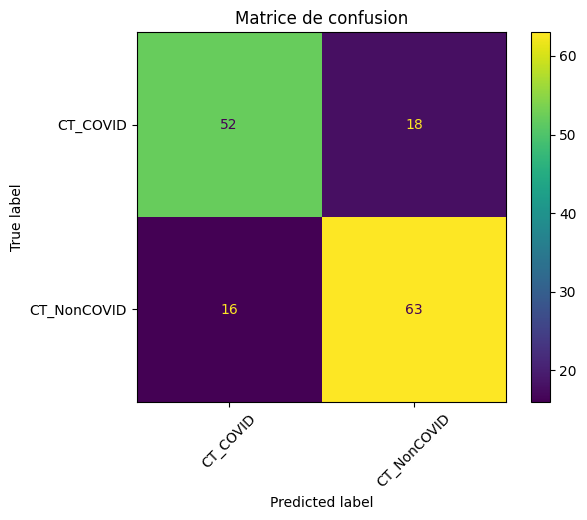

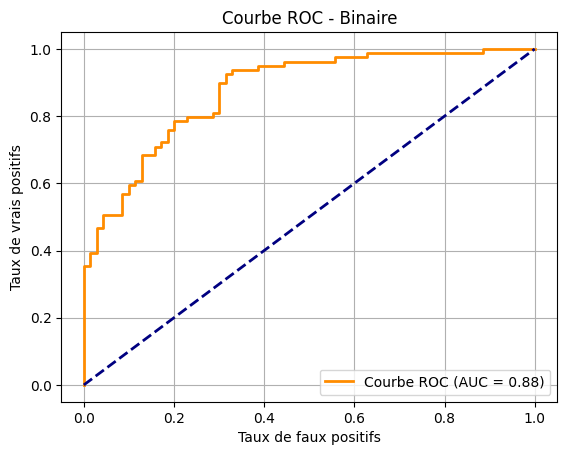

Modèle sauvegardé sous : saved_models/cnn_Covid19-XRAYS.keras

 === Dataset : DTD ===
Found 540 files belonging to 9 classes.
Using 432 files for training.
Found 540 files belonging to 9 classes.
Using 108 files for validation.
Epoch 1/20


/Users/fareselkolli/Desktop/tp2 inf 5082/tp2/.venv/lib/python3.11/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 598ms/step - accuracy: 0.1011 - loss: 2.2131 - val_accuracy: 0.0926 - val_loss: 2.1463
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 564ms/step - accuracy: 0.1521 - loss: 2.0875 - val_accuracy: 0.0926 - val_loss: 2.1763
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 562ms/step - accuracy: 0.1524 - loss: 2.1597 - val_accuracy: 0.2315 - val_loss: 2.0443
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 561ms/step - accuracy: 0.2719 - loss: 1.9906 - val_accuracy: 0.2222 - val_loss: 1.9310
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 560ms/step - accuracy: 0.3342 - loss: 1.8130 - val_accuracy: 0.3241 - val_loss: 1.8352
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 553ms/step - accuracy: 0.3209 - loss: 1.7292 - val_accuracy: 0.3333 - val_loss: 1.7838
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 564ms/step - accuracy: 0.4556 - loss: 1.6007 - val_accuracy: 0.3889 - val_loss: 1.6283
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 564ms/step - accuracy: 0.5706 - loss: 1.2241 - val_accuracy: 0.4722 - val

2025-08-02 16:41:43.716976: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


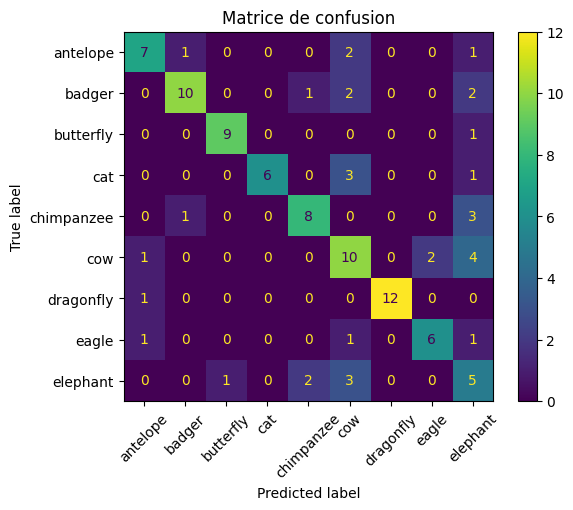

Modèle sauvegardé sous : saved_models/cnn_DTD.keras

 === Dataset : Iris ===
Found 421 files belonging to 3 classes.
Using 337 files for training.
Found 421 files belonging to 3 classes.
Using 84 files for validation.
Epoch 1/20


/Users/fareselkolli/Desktop/tp2 inf 5082/tp2/.venv/lib/python3.11/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 574ms/step - accuracy: 0.5352 - loss: 0.9500 - val_accuracy: 0.6190 - val_loss: 0.9726
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 528ms/step - accuracy: 0.6325 - loss: 0.9350 - val_accuracy: 0.6190 - val_loss: 0.9483
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 539ms/step - accuracy: 0.6405 - loss: 0.8783 - val_accuracy: 0.6190 - val_loss: 0.9505
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 552ms/step - accuracy: 0.6249 - loss: 0.8923 - val_accuracy: 0.6190 - val_loss: 0.9494
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 539ms/step - accuracy: 0.6224 - loss: 0.8827 - val_accuracy: 0.6190 - val_loss: 1.0251
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 599ms/step - accuracy: 0.6621 - loss: 0.7983 - val_accuracy: 0.6429 - val_loss: 1.0107
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 599ms/step - accuracy: 0.6829 - loss: 0.7600 - val_accuracy: 0.5238 - val_loss: 0.9859
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 585ms/step - accuracy: 0.6834 - loss: 0.7300 - val_accuracy: 0.6190 - val_

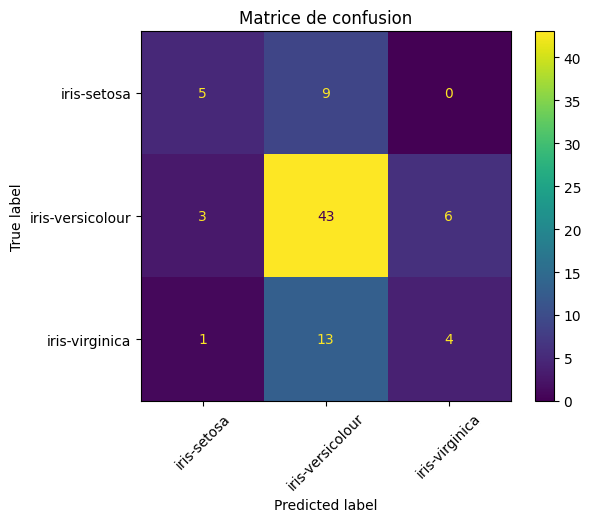

Modèle sauvegardé sous : saved_models/cnn_Iris.keras

 === Dataset : Wildfire ===
Found 1832 files belonging to 2 classes.
Using 1466 files for training.
Found 1832 files belonging to 2 classes.
Using 366 files for validation.
Epoch 1/20


/Users/fareselkolli/Desktop/tp2 inf 5082/tp2/.venv/lib/python3.11/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


46/46 ━━━━━━━━━━━━━━━━━━━━ 31s 654ms/step - accuracy: 0.7717 - loss: 0.4857 - val_accuracy: 0.9317 - val_loss: 0.1837
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 28s 611ms/step - accuracy: 0.9407 - loss: 0.1839 - val_accuracy: 0.9563 - val_loss: 0.1658
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 27s 579ms/step - accuracy: 0.9505 - loss: 0.1420 - val_accuracy: 0.9563 - val_loss: 0.1568
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 26s 554ms/step - accuracy: 0.9608 - loss: 0.1247 - val_accuracy: 0.9617 - val_loss: 0.1628
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 25s 543ms/step - accuracy: 0.9530 - loss: 0.1383 - val_accuracy: 0.9699 - val_loss: 0.0993
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 26s 571ms/step - accuracy: 0.9632 - loss: 0.1014 - val_accuracy: 0.9536 - val_loss: 0.1371
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 25s 548ms/step - accuracy: 0.9675 - loss: 0.0837 - val_accuracy: 0.9590 - val_loss: 0.1236
Epoch 8/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 25s 553ms/step - accuracy: 0.9578 - loss: 0.1010 - val_accuracy: 0.975

2025-08-02 16:52:28.732231: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


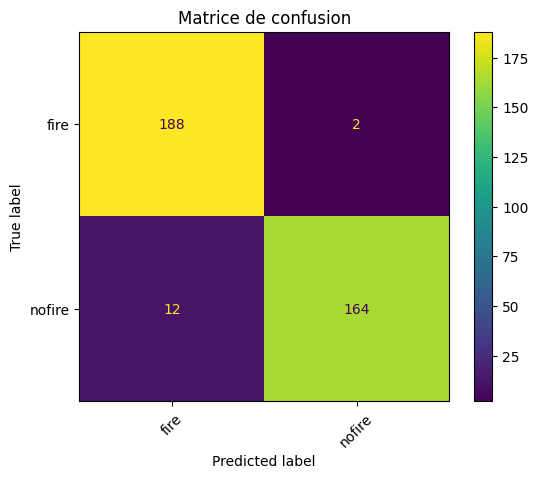

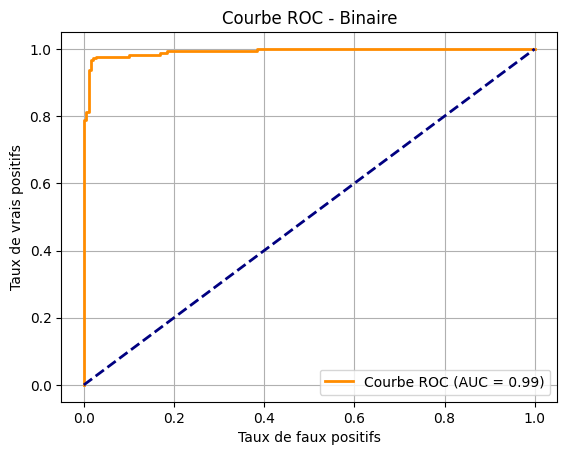

Modèle sauvegardé sous : saved_models/cnn_Wildfire.keras


In [7]:
from pathlib import Path

# Dossier contenant tous les datasets
DATA_ROOT = Path("/Users/fareselkolli/Desktop/tp2 inf 5082/tp2/data").resolve()

# Paramètres d'entraînement
img_height, img_width = 150, 150
BATCH_SIZE = 32
EPOCHS = 20

# Boucle sur chaque sous-dossier (ex: Covid19-XRAYS, DTD, Iris, Wildfire)
for dataset_dir in sorted(DATA_ROOT.iterdir()):
    if dataset_dir.is_dir():
        print(f"\n === Dataset : {dataset_dir.name} ===")

        # 1. Chargement des données
        train_ds, val_ds, class_names = load_data(dataset_dir, img_height, img_width, BATCH_SIZE)
        input_shape = (img_height, img_width, 3)

        # 2. Construction et entraînement du modèle
        model = build_model(img_height, img_width, len(class_names))
        history, train_time = train_model(model, train_ds, val_ds, EPOCHS)

        print(f"\n Temps d'entraînement pour {dataset_dir.name} : {train_time:.2f} s")

        # 3. Évaluation et métriques
        evaluate_model(model, val_ds, class_names)

        os.makedirs("saved_models", exist_ok=True)
        model_path = f"saved_models/cnn_{dataset_dir.name}.keras"
        model.save(model_path)
        print(f"Modèle sauvegardé sous : {model_path}")
